# Code Generation and Interactive Exploration

This notebook bridges symbolic derivations to executable code and interactive visualization. We demonstrate:

1. **I❤️LA Export** — Translating symbolic expressions to the I❤️LA math-to-code compiler notation
2. **Interactive Widgets** — Exploring how element properties vary with material and geometric parameters
3. **Visualization** — Plotting stiffness, condition numbers, and eigenvalue behavior

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Math, display

# Import workflow and elasticity functions
from symbolic_fem_workbench import (
    build_bar_1d_local_problem,
    build_poisson_triangle_p1_local_problem,
)
from symbolic_fem_workbench.printers.iheartla_printer import (
    iheartla_scalar_definition,
    iheartla_matrix_definition,
)

## Part A: I❤️LA Export

**I❤️LA** (Automatically generated fast Linear Algebra) is a math-to-code compiler that takes human-readable mathematical notation and generates optimized C++ code for numerical computation.

Our symbolic FEM workbench can export matrices and expressions in I❤️LA notation for further compilation. This bridges the gap between symbolic derivation and production-grade numerical kernels.

### 1D Bar Stiffness in I❤️LA

In [2]:
# Build the 1D bar problem
problem_1d = build_bar_1d_local_problem()

print("=== 1D Bar Element Stiffness Matrix ===")
print()
print(iheartla_matrix_definition("K_e", problem_1d["Ke"]))
print()
print("=== 1D Bar Element Load Vector ===")
print()
print(iheartla_matrix_definition("f_e", problem_1d["fe"]))

=== 1D Bar Element Stiffness Matrix ===

K_e = \begin{bmatrix} A*E/L & -A*E/L \
-A*E/L & A*E/L \end{bmatrix}

=== 1D Bar Element Load Vector ===

f_e = \begin{bmatrix} L*q/2 \
L*q/2 \end{bmatrix}


### 2D Poisson Triangle in I❤️LA

In [3]:
# Build the 2D Poisson problem
problem_2d = build_poisson_triangle_p1_local_problem()

print("=== 2D Poisson Triangle (Unit Right Triangle) ===")
print()
print(iheartla_matrix_definition("K_e", problem_2d["Ke_unit_right_triangle"]))
print()
print("=== 2D Poisson Load Vector ===")
print()
print(iheartla_matrix_definition("f_e", problem_2d["fe_unit_right_triangle"]))

=== 2D Poisson Triangle (Unit Right Triangle) ===

K_e = \begin{bmatrix} 1 & -1/2 & -1/2 \
-1/2 & 1/2 & 0 \
-1/2 & 0 & 1/2 \end{bmatrix}

=== 2D Poisson Load Vector ===

f_e = \begin{bmatrix} f/6 \
f/6 \
f/6 \end{bmatrix}


## Part B: Interactive Parameter Exploration

Using matplotlib and optional ipywidgets, we explore how element properties change with parameters.

### 1D Bar Stiffness vs Length

Steel bar (E=210 GPa, A=1×10⁻⁴ m²):


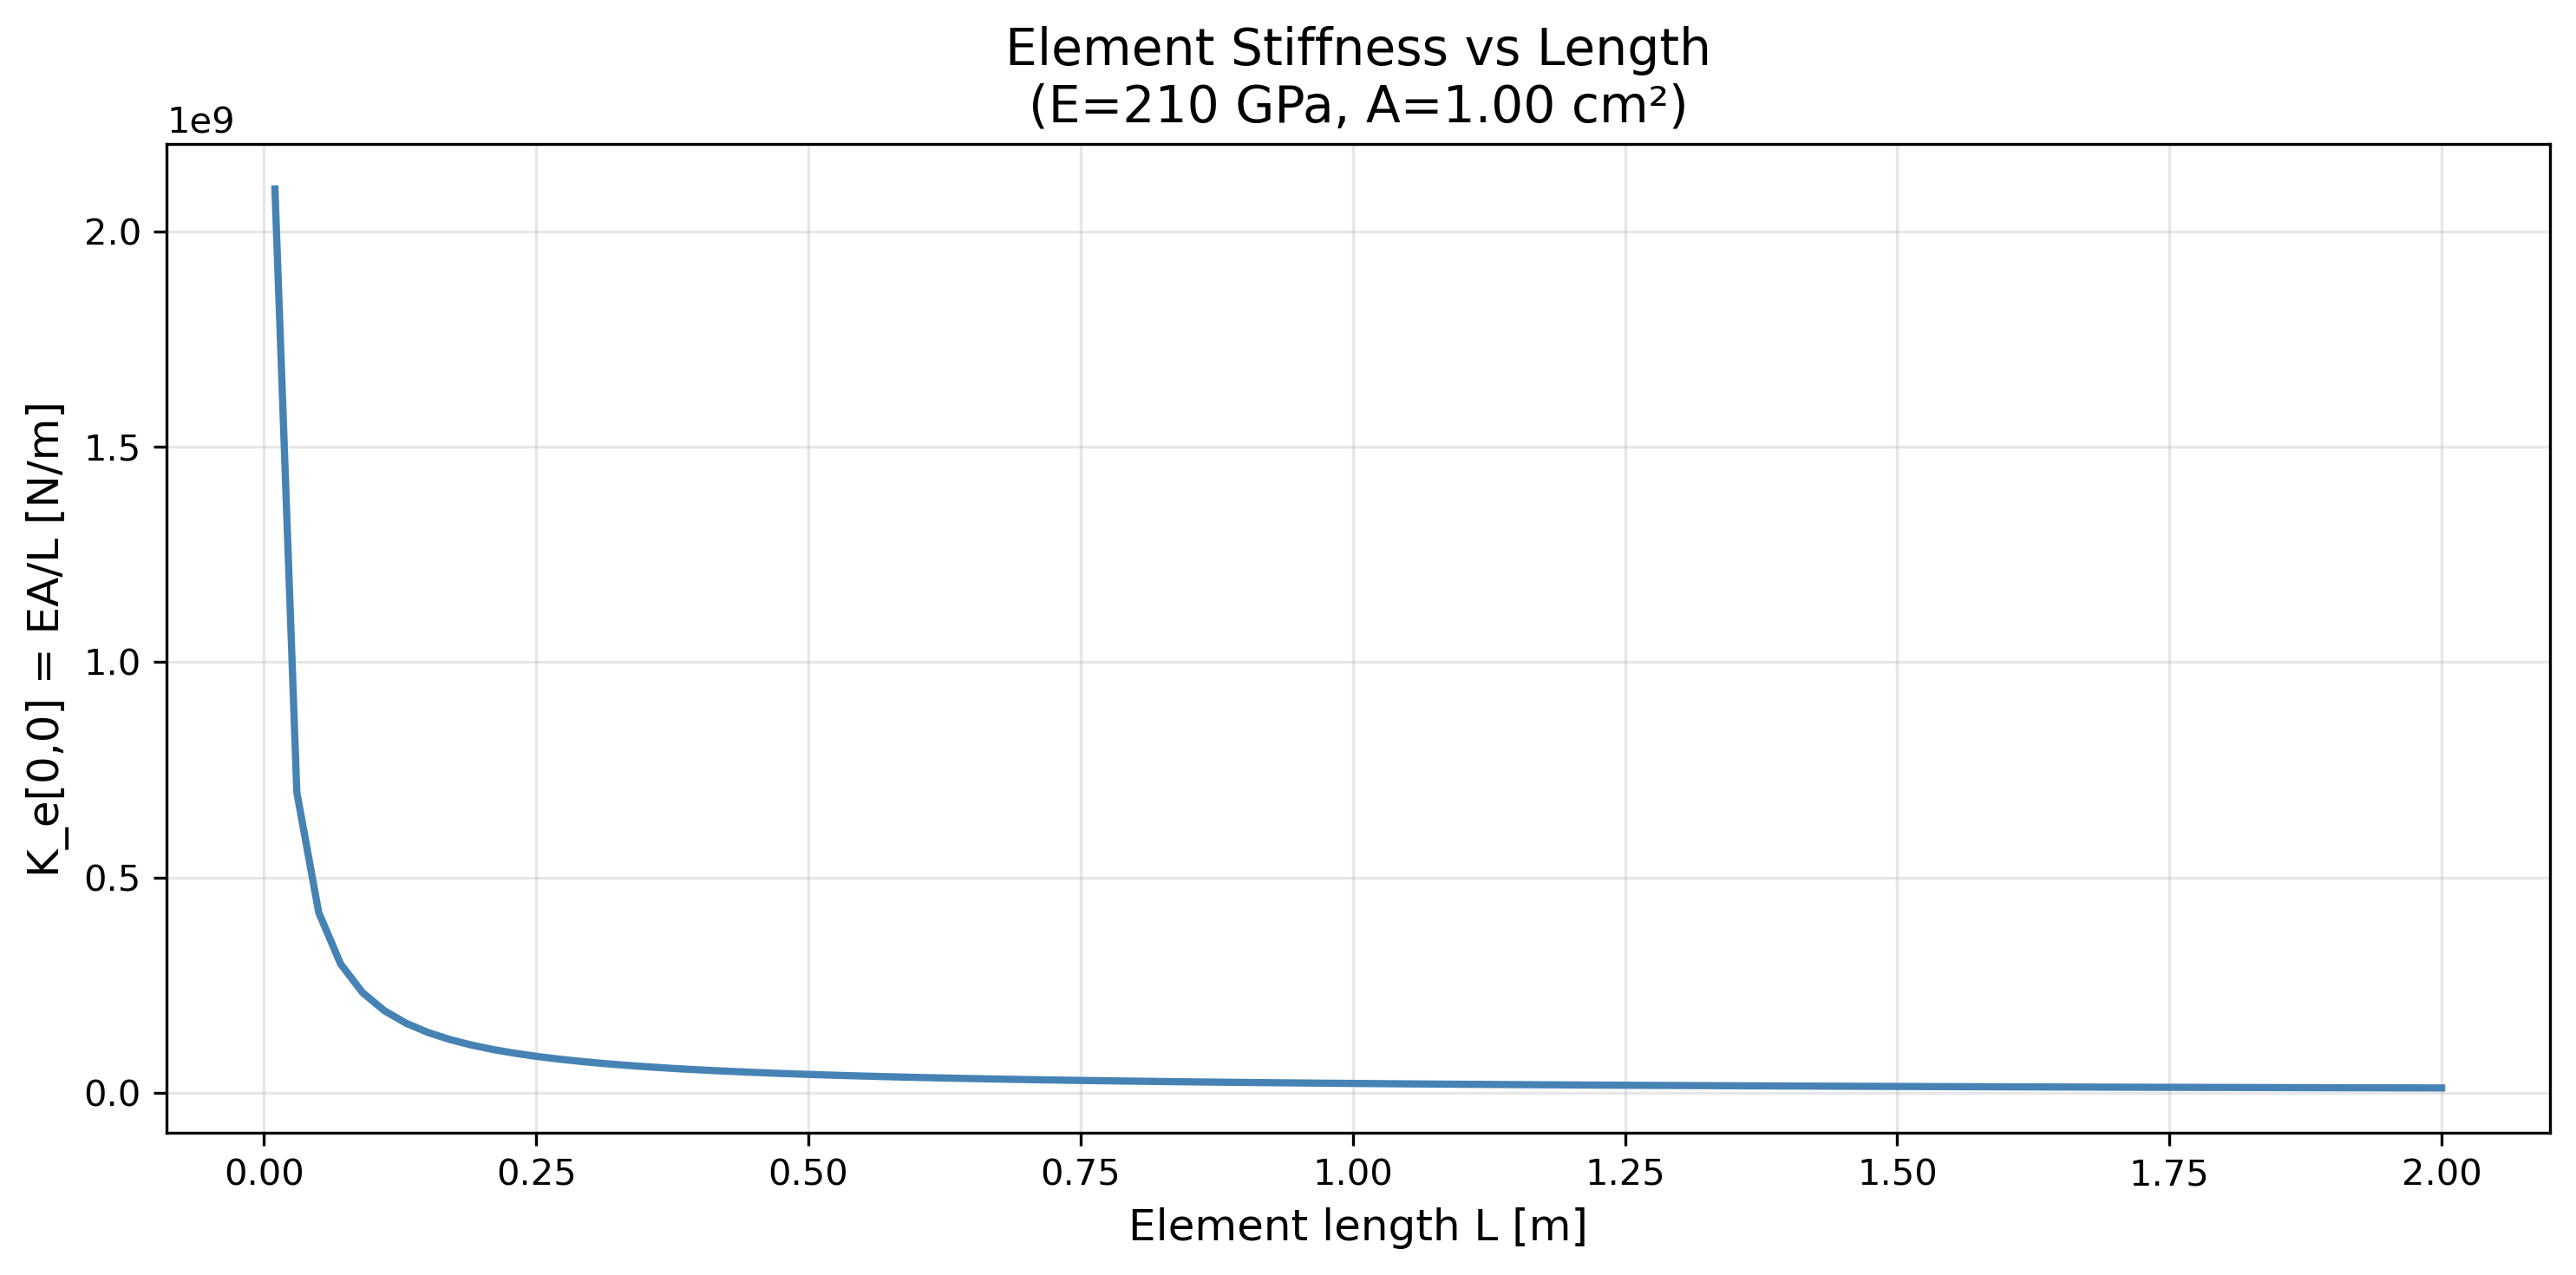


Aluminum bar (E=70 GPa, A=1×10⁻⁴ m²):


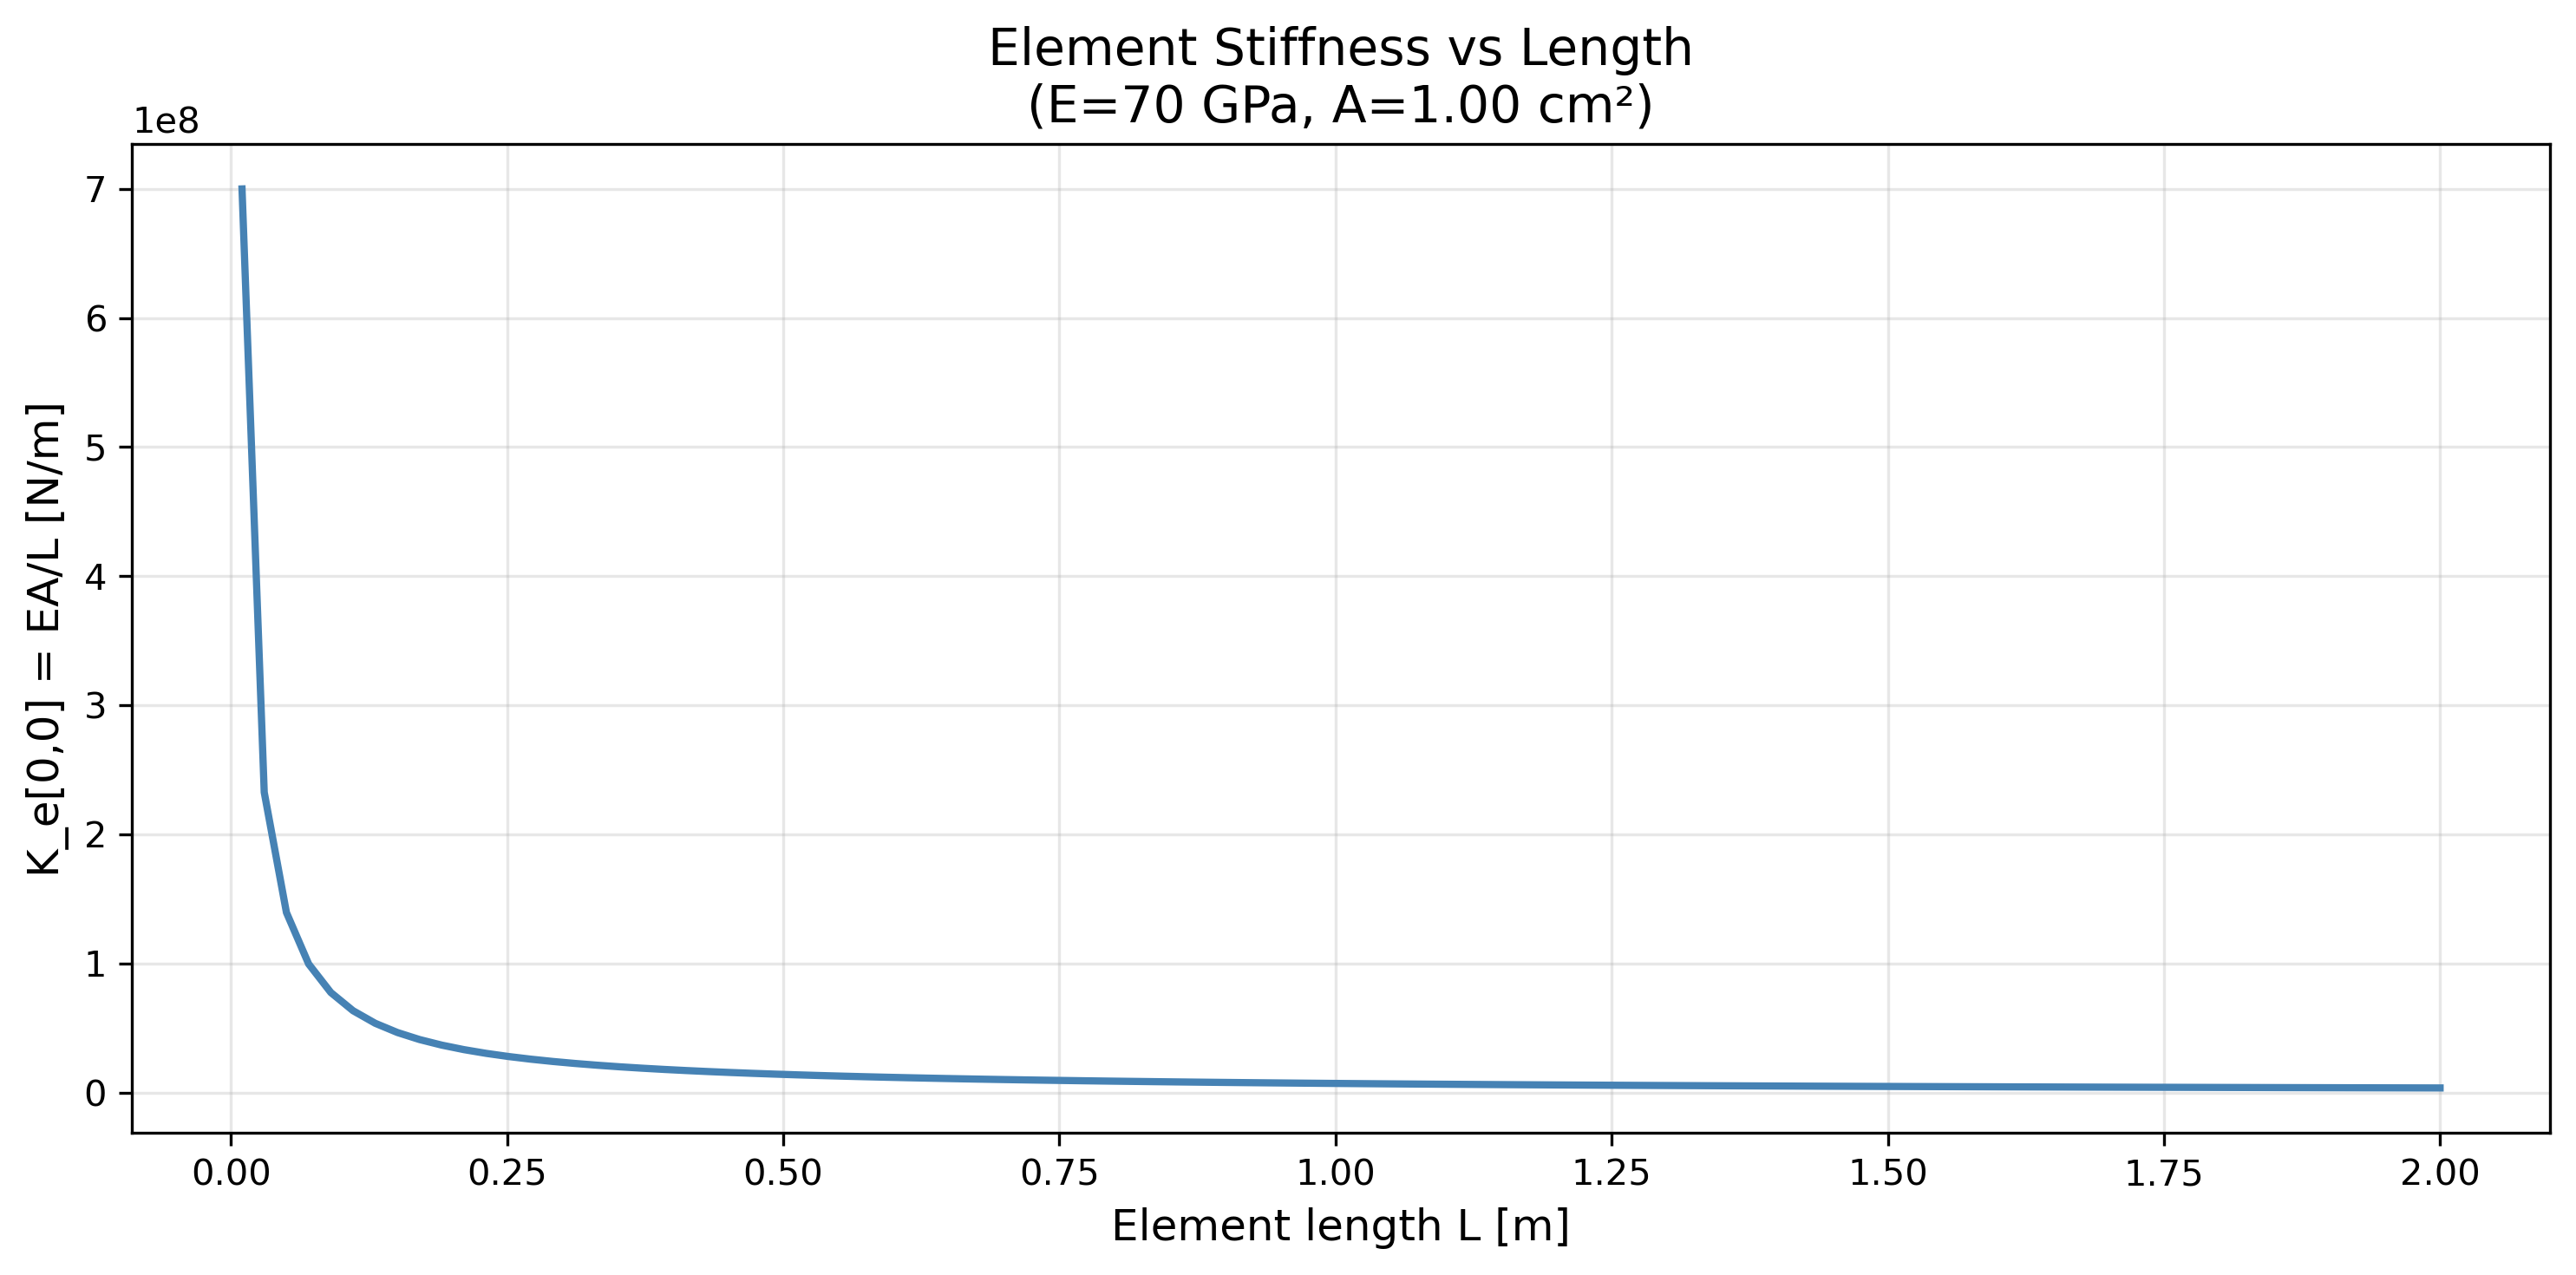

In [4]:
# Create a numpy function from the symbolic Ke
ke_fn = sp.lambdify(
    (problem_1d["L"], problem_1d["E"], problem_1d["A"]),
    problem_1d["Ke"][0, 0],  # K_e[0,0] = EA/L
    "numpy"
)

def plot_stiffness_vs_length(E_val=200e9, A_val=1e-4):
    """Show how element stiffness scales with element length."""
    lengths = np.linspace(0.01, 2.0, 100)
    k11_vals = [ke_fn(L, E_val, A_val) for L in lengths]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(lengths, k11_vals, linewidth=2, color='steelblue')
    ax.set_xlabel('Element length L [m]', fontsize=12)
    ax.set_ylabel('K_e[0,0] = EA/L [N/m]', fontsize=12)
    ax.set_title(f'Element Stiffness vs Length\n(E={E_val/1e9:.0f} GPa, A={A_val*1e4:.2f} cm²)', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Static plots with different parameters
print("Steel bar (E=210 GPa, A=1×10⁻⁴ m²):")
plot_stiffness_vs_length(E_val=210e9, A_val=1e-4)

print("\nAluminum bar (E=70 GPa, A=1×10⁻⁴ m²):")
plot_stiffness_vs_length(E_val=70e9, A_val=1e-4)

### Interactive Widgets (if ipywidgets available)

In [5]:
try:
    from ipywidgets import interact, FloatSlider
    
    @interact(
        E_val=FloatSlider(min=1e9, max=400e9, step=10e9, value=200e9, description="E [Pa]"),
        A_val=FloatSlider(min=1e-5, max=1e-2, step=1e-5, value=1e-4, description="A [m²]"),
    )
    def interactive_1d_stiffness(E_val, A_val):
        plot_stiffness_vs_length(E_val, A_val)
        
except ImportError:
    print("ipywidgets not available — using static plots above.")
    print("Install with: pip install ipywidgets")

interactive(children=(FloatSlider(value=200000000000.0, description='E [Pa]', max=400000000000.0, min=10000000…

## Part C: Interactive Triangle Deformation

Explore how the element stiffness matrix changes as we vary the triangle shape.

In [6]:
# Compile the 2D Poisson Ke into a numpy function
geom = problem_2d["geometry"]
ke_fn_2d = sp.lambdify(
    (geom.x1, geom.y1, geom.x2, geom.y2, geom.x3, geom.y3),
    problem_2d["Ke"],
    "numpy"
)

# Define several triangle configurations
configs = [
    ("Unit right triangle", (0, 0, 1, 0, 0, 1)),
    ("Equilateral", (0, 0, 1, 0, 0.5, np.sqrt(3)/2)),
    ("Isoceles right (2×2)", (0, 0, 2, 0, 0, 2)),
    ("Flat/degenerate", (0, 0, 1, 0, 0.5, 0.01)),
]

print("=== Element Stiffness Matrix Properties by Triangle Shape ===")
print(f"{'Shape':<25} {'trace(K_e)':>12} {'max|K_e|':>12} {'cond(K_e)':>12}")
print("-" * 62)

for name, (x1, y1, x2, y2, x3, y3) in configs:
    Ke = np.array(ke_fn_2d(x1, y1, x2, y2, x3, y3), dtype=float)
    trace = np.trace(Ke)
    max_val = np.max(np.abs(Ke))
    cond = np.linalg.cond(Ke)
    print(f"{name:<25} {trace:>12.4f} {max_val:>12.4f} {cond:>12.2e}")

=== Element Stiffness Matrix Properties by Triangle Shape ===
Shape                       trace(K_e)     max|K_e|    cond(K_e)
--------------------------------------------------------------
Unit right triangle             2.0000       1.0000     3.23e+32
Equilateral                     1.7321       0.5774     1.91e+16
Isoceles right (2×2)            2.0000       1.0000     3.23e+32
Flat/degenerate                75.0100      50.0000     4.14e+16


### Visualization: Stiffness vs Aspect Ratio

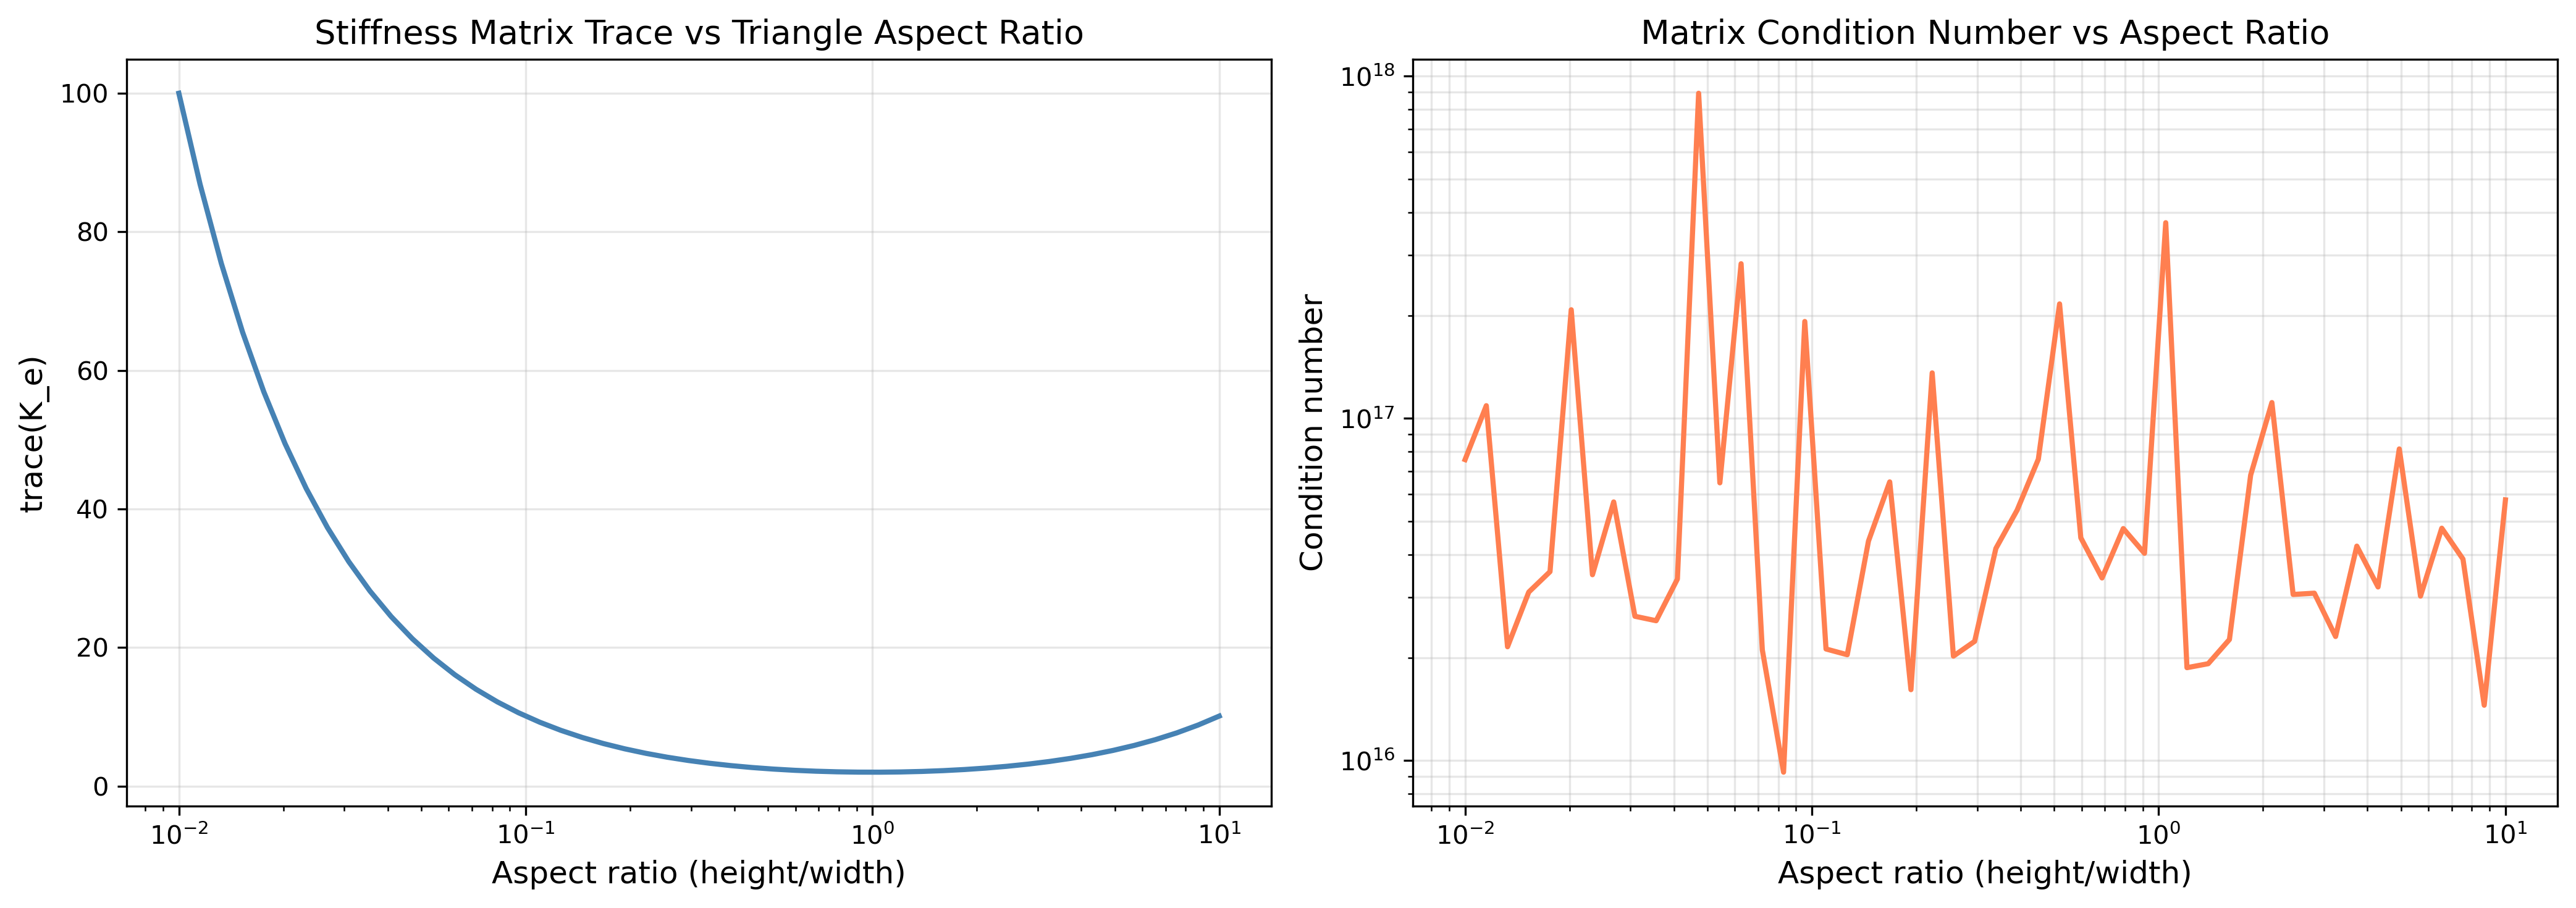


Condition number range: 9.25e+15 to 8.92e+17
Trace range: 2.0022 to 100.0100


In [7]:
# Vary the aspect ratio of an isoceles right triangle
aspect_ratios = np.logspace(-2, 1, 50)  # 0.01 to 10
traces = []
conditions = []

for ar in aspect_ratios:
    # Right triangle with legs of length 1 and ar
    Ke = np.array(ke_fn_2d(0, 0, 1, 0, 0, ar), dtype=float)
    traces.append(np.trace(Ke))
    conditions.append(np.linalg.cond(Ke))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trace
ax1.semilogx(aspect_ratios, traces, linewidth=2, color='steelblue')
ax1.set_xlabel('Aspect ratio (height/width)', fontsize=12)
ax1.set_ylabel('trace(K_e)', fontsize=12)
ax1.set_title('Stiffness Matrix Trace vs Triangle Aspect Ratio', fontsize=13)
ax1.grid(True, alpha=0.3)

# Condition number
ax2.loglog(aspect_ratios, conditions, linewidth=2, color='coral')
ax2.set_xlabel('Aspect ratio (height/width)', fontsize=12)
ax2.set_ylabel('Condition number', fontsize=12)
ax2.set_title('Matrix Condition Number vs Aspect Ratio', fontsize=13)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"\nCondition number range: {np.min(conditions):.2e} to {np.max(conditions):.2e}")
print(f"Trace range: {np.min(traces):.4f} to {np.max(traces):.4f}")

## Exercise

**Condition number analysis:**

1. Why does the condition number increase dramatically for very thin or very tall triangles?
2. What does this tell you about the numerical stability of solving systems with K_e for distorted elements?
3. Propose a mesh quality metric based on the aspect ratio that would flag problematic elements.

In [8]:
# Optional: Implement a mesh quality metric
# (Student exercise)
def element_quality_metric(x1, y1, x2, y2, x3, y3):
    """
    Define a quality metric for a triangle element.
    Some options:
      - aspect ratio
      - minimum angle
      - area-to-perimeter ratio
    """
    pass

print("Exercise: Implement element_quality_metric() above and rank the test triangles.")

Exercise: Implement element_quality_metric() above and rank the test triangles.
